# Shapash + FastAPI: real-time inference and explainability

This tutorial shows how to:
- train a tabular classification model
- compile a SmartExplainer and switch to SmartPredictor
- expose prediction and explainability through a FastAPI service

## 1. Imports and optional dependencies

In [ ]:
# Uncomment if needed
# !pip install fastapi uvicorn pydantic

import pandas as pd
from category_encoders import one_hot
from fastapi import FastAPI
from pydantic import BaseModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from shapash import SmartExplainer
from shapash.data.data_loader import data_loading
from shapash.utils.load_smartpredictor import load_smartpredictor

## 2. Train a model and compile Shapash

INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x11fe27f80>


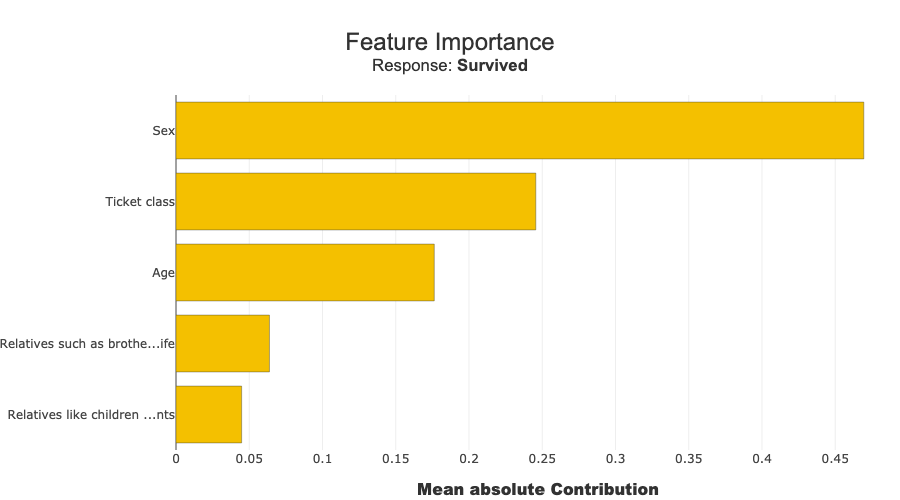

In [2]:
titanic_df, titanic_dict = data_loading('titanic')

# Keep a compact feature set for API payload simplicity
features = ['Pclass', 'Age', 'Sex', 'SibSp', 'Parch']
target = 'Survived'

df = titanic_df[features + [target]].copy()
df['Pclass'] = df['Pclass'].map({'First class': 1, 'Second class': 2, 'Third class': 3})
df['Age'] = df['Age'].fillna(df['Age'].median())

X = df[features]
y = df[target].astype(int).to_frame()

encoder = one_hot.OneHotEncoder(cols=['Sex'], use_cat_names=True).fit(X)
X_enc = encoder.transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y,
    test_size=0.25,
    random_state=79,
    stratify=y
)

clf = RandomForestClassifier(n_estimators=300, random_state=79)
clf.fit(X_train, y_train.values.ravel())

y_pred = pd.DataFrame(clf.predict(X_test), columns=['pred'], index=X_test.index)
response_dict = {0: 'Not survived', 1: 'Survived'}

xpl = SmartExplainer(
    model=clf,
    preprocessing=encoder,
    features_dict=titanic_dict,
    label_dict=response_dict,
    title_story='Titanic API tutorial'
)
xpl.compile(x=X_test, y_pred=y_pred, y_target=y_test)

xpl.plot.features_importance()

## 3. Build and persist SmartPredictor

In [3]:
predictor = xpl.to_smartpredictor()
predictor.save('predictor_fastapi.pkl')
predictor_load = load_smartpredictor('predictor_fastapi.pkl')
predictor_load

## 4. Quick local test before API

In [4]:
sample = pd.DataFrame([
    {'Pclass': 1, 'Age': 28, 'Sex': 'male', 'SibSp': 0, 'Parch': 0},
])

# SmartPredictor expects raw input with exact dtypes used at fit time
expected_types = predictor_load.features_types.copy()
sample = sample[list(expected_types.keys())].copy()

for col, dtype in expected_types.items():
    if dtype.startswith('int') or dtype.startswith('float'):
        sample[col] = pd.to_numeric(sample[col], errors='coerce').astype(dtype)
    else:
        sample[col] = sample[col].astype(dtype)

assert all(str(sample[c].dtype) == expected_types[c] for c in sample.columns), (
    sample.dtypes.astype(str).to_dict(), expected_types
)

predictor_load.add_input(x=sample)
predictor_load.modify_mask(max_contrib=4)

prediction = predictor_load.data['ypred']
proba = predictor_load.predict_proba()
explanation = predictor_load.summarize()

prediction, proba, explanation

INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x120bd3140>


(      ypred     proba
 0  Survived  0.940329,
     class_0   class_1
 0  0.059671  0.940329,
       ypred     proba     feature_1 value_1 contribution_1 feature_2 value_2  \
 0  Survived  0.940329  Ticket class       1       0.419093       Age    28.0   
 
   contribution_2 feature_3 value_3 contribution_3  \
 0       0.218704       Sex    male      -0.141945   
 
                            feature_4 value_4 contribution_4  
 0  Relatives such as brother or wife       0       0.059795  )

## 5. FastAPI app with /predict and /explain

In [5]:
class TitanicPassenger(BaseModel):
    Pclass: int
    Age: float
    Sex: str
    SibSp: int
    Parch: int


def cast_input_to_predictor_schema(x_input: pd.DataFrame) -> pd.DataFrame:
    expected_types = predictor_load.features_types.copy()
    x_cast = x_input[list(expected_types.keys())].copy()

    for col, dtype in expected_types.items():
        if dtype.startswith('int') or dtype.startswith('float'):
            x_cast[col] = pd.to_numeric(x_cast[col], errors='coerce').astype(dtype)
        else:
            x_cast[col] = x_cast[col].astype(dtype)
    return x_cast


app = FastAPI(title='Shapash SmartPredictor API')


@app.get('/health')
def health():
    return {'status': 'ok'}


@app.post('/predict')
def predict(payload: TitanicPassenger):
    x_input = pd.DataFrame([payload.model_dump()])
    x_input = cast_input_to_predictor_schema(x_input)
    predictor_load.add_input(x=x_input)

    ypred_df = predictor_load.data['ypred']
    ypred_value = ypred_df.iloc[0, 0]

    proba_df = predictor_load.predict_proba()
    proba_dict = proba_df.iloc[0].to_dict()

    return {
        'prediction': ypred_value,
        'predict_proba': proba_dict
    }


@app.post('/explain')
def explain(payload: TitanicPassenger):
    x_input = pd.DataFrame([payload.model_dump()])
    x_input = cast_input_to_predictor_schema(x_input)
    predictor_load.add_input(x=x_input)
    predictor_load.modify_mask(max_contrib=4)

    detail = predictor_load.detail_contributions()
    summary = predictor_load.summarize()

    if hasattr(detail, 'to_dict'):
        detail_out = detail.to_dict(orient='records')[0]
    else:
        detail_out = detail

    if hasattr(summary, 'to_dict'):
        summary_out = summary.to_dict(orient='records')[0]
    else:
        summary_out = summary

    return {
        'detail_contributions': detail_out,
        'summary': summary_out
    }

## 6. Run and test API (optional)

Create the API file from this notebook (next cell), then run in a terminal from repo root:
- `uvicorn tutorial.fastapi_app:app --reload --port 8000`

Then open:
- `http://127.0.0.1:8000/health`
- `http://127.0.0.1:8000/docs`

In [6]:
%%writefile fastapi_app.py
from pathlib import Path

import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel

from shapash.utils.load_smartpredictor import load_smartpredictor

BASE_DIR = Path(__file__).resolve().parent
PREDICTOR_PATH = BASE_DIR / 'predictor_fastapi.pkl'
predictor_load = load_smartpredictor(str(PREDICTOR_PATH))


class TitanicPassenger(BaseModel):
    Pclass: int
    Age: float
    Sex: str
    SibSp: int
    Parch: int


def cast_input_to_predictor_schema(x_input: pd.DataFrame) -> pd.DataFrame:
    expected_types = predictor_load.features_types.copy()
    x_cast = x_input[list(expected_types.keys())].copy()

    for col, dtype in expected_types.items():
        if dtype.startswith('int') or dtype.startswith('float'):
            x_cast[col] = pd.to_numeric(x_cast[col], errors='coerce').astype(dtype)
        else:
            x_cast[col] = x_cast[col].astype(dtype)
    return x_cast


app = FastAPI(title='Shapash SmartPredictor API')


@app.get('/health')
def health():
    return {'status': 'ok'}


@app.post('/predict')
def predict(payload: TitanicPassenger):
    x_input = pd.DataFrame([payload.model_dump()])
    x_input = cast_input_to_predictor_schema(x_input)
    predictor_load.add_input(x=x_input)

    ypred_df = predictor_load.data['ypred']
    ypred_value = ypred_df.iloc[0, 0]

    proba_df = predictor_load.predict_proba()
    proba_dict = proba_df.iloc[0].to_dict()

    return {
        'prediction': ypred_value,
        'predict_proba': proba_dict,
    }


@app.post('/explain')
def explain(payload: TitanicPassenger):
    x_input = pd.DataFrame([payload.model_dump()])
    x_input = cast_input_to_predictor_schema(x_input)
    predictor_load.add_input(x=x_input)
    predictor_load.modify_mask(max_contrib=4)

    detail = predictor_load.detail_contributions()
    summary = predictor_load.summarize()

    if hasattr(detail, 'to_dict'):
        detail_out = detail.to_dict(orient='records')[0]
    else:
        detail_out = detail

    if hasattr(summary, 'to_dict'):
        summary_out = summary.to_dict(orient='records')[0]
    else:
        summary_out = summary

    return {
        'detail_contributions': detail_out,
        'summary': summary_out,
    }

Overwriting fastapi_app.py


## 7. API tests from notebook

Run these cells after starting the API with:
`uvicorn tutorial.fastapi_app:app --reload --port 8000`

In [7]:
import requests

BASE_URL = 'http://127.0.0.1:8000'

def show_response(resp):
    print('status:', resp.status_code)
    try:
        return resp.json()
    except Exception:
        return resp.text

In [8]:
# 1) Health check
resp = requests.get(f'{BASE_URL}/health', timeout=10)
show_response(resp)

status: 200


{'status': 'ok'}

In [9]:
# 2) Predict endpoint
payload = {
    'Pclass': 3,
    'Age': 24.0,
    'Sex': 'female',
    'SibSp': 0,
    'Parch': 0,
}
resp = requests.post(f'{BASE_URL}/predict', json=payload, timeout=20)
show_response(resp)

status: 200


{'prediction': 'Not survived',
 'predict_proba': {'class_0': 0.7975449735449736,
  'class_1': 0.20245502645502644}}

In [10]:
# 3) Explain endpoint
resp = requests.post(f'{BASE_URL}/explain', json=payload, timeout=30)
show_response(resp)

status: 200


{'detail_contributions': {'ypred': 'Not survived',
  'proba': 0.7975449735449736,
  'Pclass': 0.1632976894295741,
  'Age': 0.17053304797895122,
  'Sex': -0.22136818570220265,
  'SibSp': 0.022301925827067973,
  'Parch': 0.04572959780799086},
 'summary': {'ypred': 'Not survived',
  'proba': 0.7975449735449736,
  'feature_1': 'Sex',
  'value_1': 'female',
  'contribution_1': -0.22136818570220265,
  'feature_2': 'Age',
  'value_2': 24.0,
  'contribution_2': 0.17053304797895122,
  'feature_3': 'Ticket class',
  'value_3': 3,
  'contribution_3': 0.1632976894295741,
  'feature_4': 'Relatives like children or parents',
  'value_4': 0,
  'contribution_4': 0.04572959780799086}}